
<div style=" display: flex; align-items: center; justify-content: space-between; padding: 20px; border-bottom: 3px solid #1f2937;">
    <div style="flex: 1; text-align: left;">
        <img src="Images/Elevvo Logo.png" style="height:80px;">
    </div>
    <div style="flex: 2; text-align: center;">
        <h1 style="margin:0; font-size:28px; font-weight:700;">
        Customer Segmentation
        </h1>
    </div>
    <div style="flex: 1; text-align: right; margin-right: 50px;">
        <img src="Images/logo.png" style="height:100px;">
    </div>
</div>

# Customer Segmentation Project

# Introduction

Customer segmentation is an important technique used in data analysis and business intelligence which aims to group customers together by characteristics that they have in common. Companies can identify the characteristics of customers with similar behaviours, and subsequently produce targeted marketing strategies for each segment.

Within this project, we will implement unsupervised learning methods in order to create customer segments based on the Mall Customers dataset. The segments created will consist of Annual Income and Spending Score, and we will perform data exploration and feature scaling, and will use K-Means clustering to derive the optimum number of customer segments based using the Elbow Method. 

We will also evaluate K-Means against DBSCAN, which will provide us with different perspectives on how each method is able to produce differing clusters for the same dataset, as well as provide evidence to prove whether there are distinct or meaningful customer segments to be identified and subsequently analysed from a business perspective.

## Step 1: Upload and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Load Dataset

In [2]:
# Load dataset from local path
df = pd.read_csv(r"D:\Customer Segmintation\Dataset\Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 2: Basic Data Exploration

In [3]:
# Dataset shape
df.shape

(200, 5)

In [4]:
# Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Check missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 3: Data Visualization

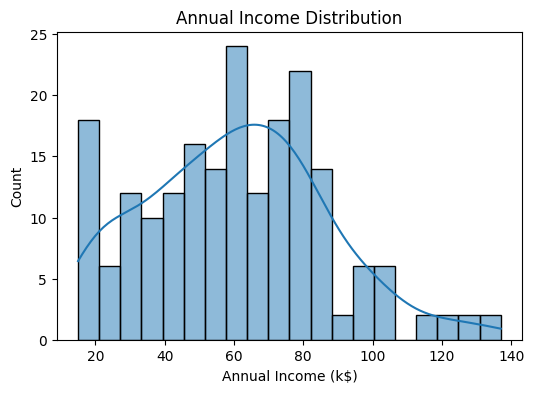

In [7]:
# Distribution of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

The histogram plot provides a visual representation of how much money customers make annually (in USD thousands). The x-axis displays income in thousands of USD, while the y-axis displays how many customers corresponded to the given income range (or bin). The majority of customers are within the income range of about 40000 to 80000 (occur most frequently between 50000 and 70000) as suggested by the highest bars and also indicated by the peak of the smooth blue density estimator curve (KDE). In contrast, there are only a few customers with very low income (less than or equal to 30000) and very high income (greater than or equal to 100000) which results in a slight positive skews to the distribution from the outlier highs that extend from approximately 130000 to 140000. In summary, the histogram indicates that most of the customer population is concentrated around average-middle income. Fewer customers are located in the extreme ends of income distribution.

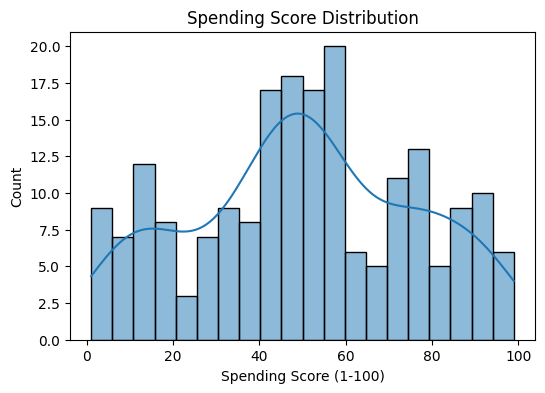

In [8]:
# Distribution of Spending Score
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

The Customers’ Spending Score (1 to 100) Histogram shows how the customers’ spending scores are distributed. The x-axis represents spending score while y-axis shows how many customers fall within each of the specified scoring ranges. Most Spending Scores cluster around the mid-range (approximately 40-60 range) where maximum number of customers lie and where the area of the density curve peaks. Noticeable groups also exist at low spending scores (0 to 30) as well as high spending scores (70 to 100). The density curve has a fairly normal-looking distribution and is somewhat more closely clustered toward the centre thus indicating a significant number of spending behaviours are at a fairly moderate level of spending, with there being fewer low and high spending behaviours.

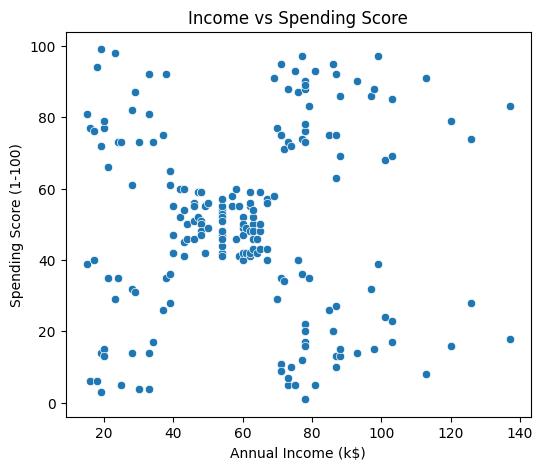

In [19]:
# Income vs Spending Score
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

The scatter plot shows the relationship between Annual Income (k$) and Spending Score (1-100). Each point represents a customer.

The scatter plot does not show a strong linear relationship between these two variables; rather than having either an upward or downward trend, the points are more clustered and grouped together. Some notable examples of this are:

1) A large concentration of points in the middle at a range of approximately $40,000-$70,000 income for a spending score of between 40-60 indicating moderate income/mid-level spending customers

2) A concentration of high income customers (> $70,000) with low spending scores (10-30); 

3) A concentration of high income customers ($70,000+) and high spending scores (70-100); 

4) A small number of very low income customers who are both low and high spending;

The clusters on this scatter plot indicate that customers group themselves naturally into defined market segments, therefore this dataset can be analyzed using clustering techniques such as K-Means. Because there is no clearly defined linear trend in the data, the use of clustering techniques will be better suited than using regression analysis to analyze this dataset.

## Step 4: Feature Selection and Scaling

In [9]:
# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Apply Standard Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [11]:
# Convert back to DataFrame for inspection
X_scaled_df = pd.DataFrame(
    X_scaled, 
    columns=['Annual Income (scaled)', 'Spending Score (scaled)']
)
pd.set_option('display.float_format', '{:.3f}'.format)

X_scaled_df.describe()

,Annual Income (scaled),Spending Score (scaled)
count,200.000,200.000
mean,-0.000,-0.000
std,1.003,1.003
min,-1.739,-1.910
25%,-0.728,-0.600
50%,0.036,-0.008
75%,0.666,0.885
max,2.918,1.894


## Step 5: Determine Optimal Number of Clusters (Elbow Method)

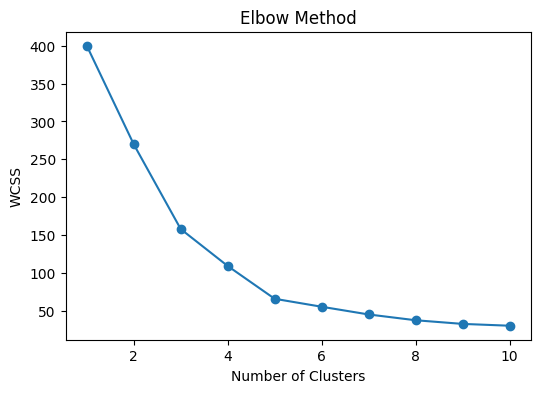

In [12]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In the Elbow Method plot, we see how the Within-Cluster Sum of Squares (WCSS) volume changes as we increase the number of clusters (k) from 1 to 10. The WCSS value shows how much distance all the data points are from their assigned cluster centroids; thus, the lower the WCSS value the more “compact” the cluster is. In this case, we see a very steep drop in the WCSS from the one cluster to 4 clusters, which indicates that adding more clusters does a very good job at grouping the data points together. However, after approximately the k=5 cluster mark we see that the drops in WCSS are getting much less steep, which means adding more clusters provides very small increases in cluster quality (grouping). The elbow of the graph is where the WCSS transition from steep to less steep drops occur, which indicates that 5 is the proper number of clusters for the data (also provides an appropriate level of model simplicity versus clustering quality).

## Step 6: Apply K-Means Clustering

In [13]:
# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [14]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [15]:
# Cluster centers (scaled space)
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [16]:
# Convert cluster centers back to original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

pd.DataFrame(
    centroids,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

,Annual Income (k$),Spending Score (1-100)
0,55.296,49.519
1,86.538,82.128
2,25.727,79.364
3,88.200,17.114
4,26.304,20.913


## Step 7: Visualize Customer Segmen

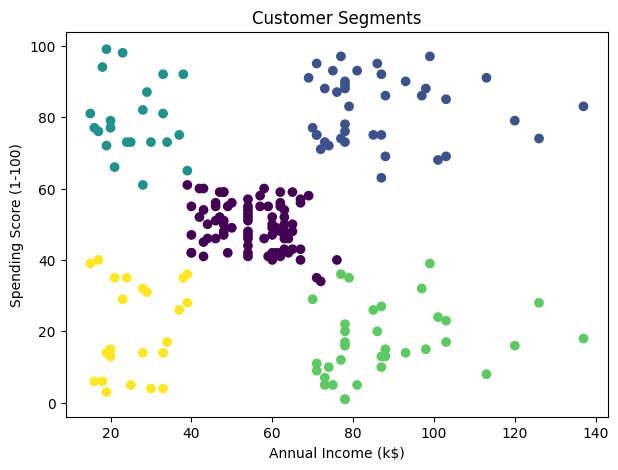

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()

This diagram illustrates the **final result of cluster analysis using K-Means**, with customers clustered into their own separate categories based upon two factors: **Annual Income and Spending Score**. Each unique color represents its own respective cluster (or segment of customers).

There appears to be **five distinct clusters** of customer groups present in the data:

1. **Low Annual Income (15K < 35K) and Low Spending (0 < 40)** (located in the bottom left corner) — customers with lower than average incomes (15,000 - 35,000) and low levels of spending (0 - 40) indicating these customers are budget conscious or have low purchasing powers.

2. **Low Annual Income (20K < 40K) and High Spending (70 < 100)** (located in the top left corner) — customers in this category earn lower than average incomes (20,000 - 40,000), but display high levels of spending (70 - 100), indicating potential for impulse buying or high engagement levels with shoppers.

3. **Average Annual Income (40K < 70K) and Average Spending (40 < 60)** (located in the center) — this segment contains customers who earn on average (40,000 - 70,000) and spend on average (40 - 60), providing this segment with more stability than any of the other segments.

4. **High Annual Income (70K+) and Low Spending (0 < 40)** (located in bottom right) — these customers have a large amount of purchasing power (as demonstrated by their incomes) yet spend relatively little on average (0 - 40). Consequently, this segment should represent a major target market for other marketing efforts.

5. **High Annual Income (70K+) and High Spending (70 < 100)** (located in the upper right corner) — customers who fall into this category have an income of over $70,000 and are spending heavily (70 - 100). These customers are the premium customers, and likely represent some of the best customer segments available to retailers; consequently they will be the most valuable segments to retailers.

This visualization confirms that the dataset naturally forms **distinct customer segments**, which is why K-Means works well here. Instead of a linear relationship, customers group into behavioral categories, making segmentation useful for targeted marketing strategies.

## Apply DBSCAN Clustering

In [21]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

# Add DBSCAN cluster labels
df['DBSCAN_Cluster'] = db_clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,4,0
1,2,Male,21,15,81,2,0
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,0
4,5,Female,31,17,40,4,0


In [22]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64

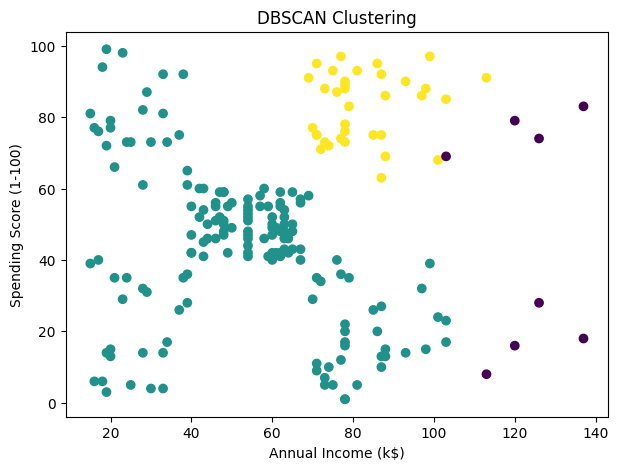

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['DBSCAN_Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.show()

This plot illustrates the results obtained from applying **DBSCAN clustering** to this same dataset of Annual Income compared to Spending Score. DBSCAN creates groups by **density**, rather than having to assign a pre-defined number of clusters as is the case in K-Means. The following observations can be made based on the visual representation of the cluster formations.

* There is a large central cluster represented by teal, that captures all of the customers with a middle range income and a middle range spending score as well as other additional customers nearby. As a result of this, DBSCAN will tend to combine closely located, but different density areas into one large cluster.
* There is also clearly defined cluster of customers located in the upper-right area that are classified as having a high income and a high spending score (yellow color). This cluster, by itself is highly dense.
* In addition, there are several points located on the far right of the dataset (purple) that appear to be isolated. These points are likely classified as **noise or outliers** (i.e.—Cluster `-1`) because they do not belong to any defined zone of high density.
* Customers who have low income present will also not be as easily segregated as they were using K-Means algorithm (low income customers with either a low or high spending score were mainly located with other customers in the central high density cluster).

### The main differences between this clustering result in DBSCAN and the K-Means clustering result are as follows:

* **K-Means** created 5 clearly defined and well-balanced clusters.
* **DBSCAN** has combined clusters as one and has defined the outliers automatically.
* K-Means is defined by its defined number of clusters, but DBSCAN has the added benefit of being able to find noise within the cluster and can adopt an irregular shaped cluster if it can combine the clusters into one based on density levels.

Overall, DBSCAN provides a more density-based view of the data, highlighting core dense groups and isolating unusual customers, while K-Means provides clearer business-oriented segmentation.

## Cluster Business Analysis

In [25]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296,49.519
1,86.538,82.128
2,25.727,79.364
3,88.200,17.114
4,26.304,20.913


In [26]:
cluster_summary['Customer Count'] = df['Cluster'].value_counts().sort_index()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,
0,55.296,49.519,81
1,86.538,82.128,39
2,25.727,79.364,22
3,88.200,17.114,35
4,26.304,20.913,23


In [29]:
from sklearn.metrics import silhouette_score

# K-Means silhouette score
kmeans_score = silhouette_score(X_scaled, df['Cluster'])

# DBSCAN silhouette score (remove noise points)
dbscan_labels = df['DBSCAN_Cluster']
mask = dbscan_labels != -1

dbscan_score = silhouette_score(X_scaled[mask], dbscan_labels[mask])

print(f"K-Means Silhouette Score: {kmeans_score:.3f}")
print(f"DBSCAN Silhouette Score: {dbscan_score:.3f}")

K-Means Silhouette Score: 0.555
DBSCAN Silhouette Score: 0.388


In [30]:
print("K-Means distribution:\n", df['Cluster'].value_counts())
print("\nDBSCAN distribution:\n", df['DBSCAN_Cluster'].value_counts())

K-Means distribution:
 Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

DBSCAN distribution:
 DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


# Conclusion

To conclude, this project accomplished the goal of performing customer segmentation via the use of clustering algorithms. After examining an existing data set and scaling it for analysis, we were able to use the Elbow Method to determine the best number of clusters, which was 5. The K-Means Clustering algorithm performed well and provided 5 clear and balanced clusters based on income and spending habits that can be classified as various types of consumers: high-income and high-spending consumers, low-income and high-spending consumers, and conservative consumers with high-income but low-spending habits. These different types of consumers provide insight into the business for developing methods to market products more precisely and provide strategic direction in the future.

The DBScan clustering algorithm was evaluated for comparison to K-Means. DBScan produced fewer clusters and classifies many of the data points as being located in an area with no density, thus suggesting that the structure of the data is more suited to clustering based on distance than clustering based on density.

The results of both clustering algorithms demonstrate that K-Means is a better fit for this particular data set because it represents the underlying customer base and gives the business valuable information to analyze their customers in meaningful ways.